# BiLSTM News Source Classifier

Binary classification of news headlines (Fox News / NBC News)
using a from-scratch **Bidirectional LSTM** with a learned embedding layer.

---

## Model Architecture

```
Input headline (tokenised, max 80 tokens)
        │
        ▼
┌─────────────────────────────────────┐
│  Embedding  (vocab × 128)           │
│  SpatialDropout(p=0.40)             │  ← drops entire channels across all time-steps
└─────────────────────────────────────┘
        │  B × T × 128
        ▼
┌─────────────────────────────────────┐
│  Bidirectional LSTM                 │
│    layers : 2                       │
│    hidden : 256  (×2 directions)    │
│    dropout: 0.40 between layers     │
└─────────────────────────────────────┘
        │  B × T × 512
        ▼
┌─────────────────────────────────────┐
│  Triple Pooling  (concat)           │
│  ├─ Bahdanau attention  → 512       │  ← tanh(W·h) → v, learned importance
│  ├─ Max pooling         → 512       │  ← most discriminative feature per channel
│  └─ Mean pooling        → 512       │  ← overall headline tone
└─────────────────────────────────────┘
        │  B × 1536
        ▼
┌─────────────────────────────────────┐
│  MLP Classifier                     │
│  LayerNorm(1536)                    │
│  Linear(1536 → 256) + GELU         │
│  Dropout(p=0.40)                    │
│  Linear(256 → 2)                   │
└─────────────────────────────────────┘
        │
        ▼
  logits [fox, nbc]
```

**Training details:** AdamW / Adam · label smoothing 0.05 · early stopping (patience 5) · multi-seed ensemble (5 seeds)

### Setup

In [1]:
# ── install ───────────────────────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'pandas', 'scikit-learn', 'tqdm', 'matplotlib', '-q'],
               check=True)

# ── stdlib ────────────────────────────────────────────────────────────────────
import os, re
from collections import Counter
from dataclasses import dataclass, field

# ── torch ─────────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import OneCycleLR

# ── ml / viz ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings; warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10, 'axes.spines.top': False,
                     'axes.spines.right': False})

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device → {DEVICE}" + (f"  ({torch.cuda.get_device_name(0)})" if DEVICE.type == 'cuda' else
      "  ← no GPU, switch runtime for faster training"))

device → cuda  (Tesla T4)


### Hyperparameters & Experiment Grid

In [2]:
CFG = dict(
    # data
    csv             = 'data/headlines_scraped.csv',
    val_frac        = 0.15,
    seed            = 42,
    # vocabulary
    vocab_cap       = 20_000,
    min_freq        = 2,
    seq_len         = 80,
    # model
    emb_dim         = 128,
    hid_dim         = 256,
    n_layers        = 2,
    drop_p          = 0.40,
    n_cls           = 2,
    # training
    batch_sz        = 64,
    n_epochs        = 25,
    label_smoothing = 0.05,       # model no longer overfits — soften less
    patience        = 5,
    # output
    ckpt            = 'model.pt',
    cls_names       = {0: 'foxnews', 1: 'nbcnews'},
)

# ── grid: Adam variants first since they keep winning ─────────────────────────
GRID = [
    dict(tag='Adam  · lr=1e-3',            opt='Adam',  lr=1e-3, wd=0.00),
    dict(tag='Adam  · lr=2e-3',            opt='Adam',  lr=2e-3, wd=0.00),
    dict(tag='Adam  · lr=5e-4',            opt='Adam',  lr=5e-4, wd=0.00),
    dict(tag='AdamW · lr=1e-3 · wd=5e-3', opt='AdamW', lr=1e-3, wd=0.005),
    dict(tag='AdamW · lr=2e-3 · wd=1e-2', opt='AdamW', lr=2e-3, wd=0.010),
    dict(tag='AdamW · lr=1e-3 · wd=1e-2', opt='AdamW', lr=1e-3, wd=0.010),
]

torch.manual_seed(CFG['seed']); np.random.seed(CFG['seed'])
print(f"{len(GRID)} runs scheduled")
for g in GRID:
    print(f"  {g['tag']:<35}  wd={g['wd']}")

6 runs scheduled
  Adam  · lr=1e-3                      wd=0.0
  Adam  · lr=2e-3                      wd=0.0
  Adam  · lr=5e-4                      wd=0.0
  AdamW · lr=1e-3 · wd=5e-3            wd=0.005
  AdamW · lr=2e-3 · wd=1e-2            wd=0.01
  AdamW · lr=1e-3 · wd=1e-2            wd=0.01


### Data — Load & Explore

rows=3,804   fox=2,000   nbc=1,804
headline tokens  min=2  max=24  avg=12.7


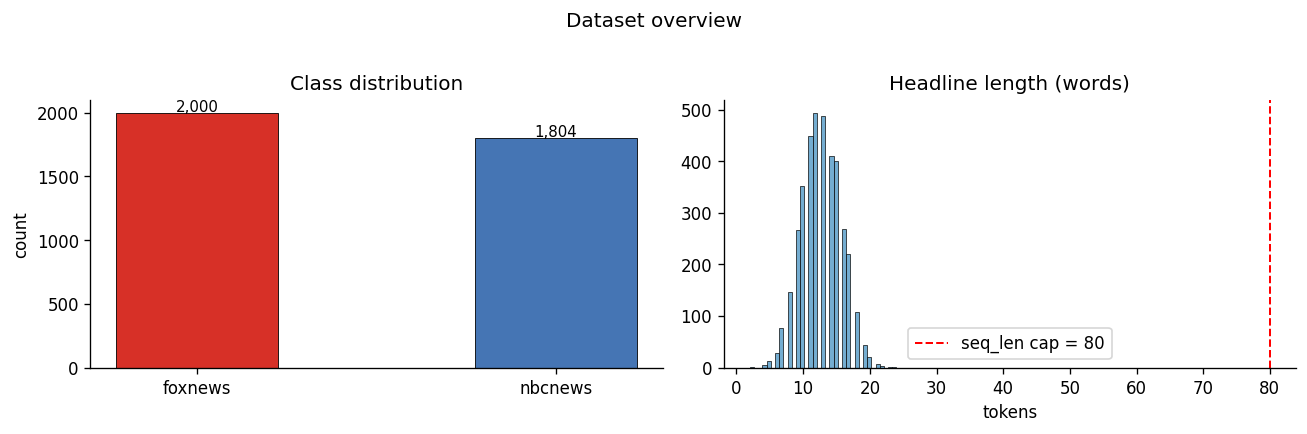

saved → eda.png


In [ ]:
raw = pd.read_csv(CFG['csv']).dropna(subset=['headline', 'label'])
raw['label'] = raw['label'].astype(int)

X = raw['headline'].tolist()          # all headlines
y = raw['label'].tolist()             # all targets (0 / 1)

### Train / Val Split

In [4]:
from sklearn.model_selection import train_test_split

X_tr, X_va, y_tr, y_va = train_test_split(
    X, y,
    test_size=CFG['val_frac'],
    stratify=y,
    random_state=CFG['seed'],
)
print(f"train={len(X_tr):,}   val={len(X_va):,}")

train=3,233   val=571


### Vocabulary

In [5]:
class Vocab:
    """Tokeniser + word-index lookup, built from training split only."""
    PAD, UNK = 0, 1

    def __init__(self, corpus, cap: int, min_freq: int):
        freq = Counter(tok for sent in corpus for tok in self._lex(sent))
        self._w2i = {'<pad>': self.PAD, '<unk>': self.UNK}
        for w, c in freq.most_common(cap - 2):
            if c < min_freq:
                break
            self._w2i[w] = len(self._w2i)
        self.freq = freq

    @staticmethod
    def _lex(text: str):
        # keep words/numbers AND punctuation signals (?  !)
        return re.findall(r"[a-z0-9']+|[?!]", text.lower())

    def encode(self, text: str, maxlen: int):
        toks = self._lex(text)[:maxlen]
        ids  = [self._w2i.get(t, self.UNK) for t in toks]
        n    = max(len(ids), 1)
        ids += [self.PAD] * (maxlen - len(ids))
        return ids, n

    def __len__(self): return len(self._w2i)


tok = Vocab(X_tr, CFG['vocab_cap'], CFG['min_freq'])
cov = sum(1 for w in tok.freq if w in tok._w2i) / len(tok.freq) * 100
print(f"|vocab| = {len(tok):,}   train coverage = {cov:.1f}%")
print("top tokens:", ', '.join(w for w, _ in tok.freq.most_common(10)))

|vocab| = 4,020   train coverage = 45.4%
top tokens: to, in, of, the, for, trump, on, and, a, harris


### Dataset & DataLoaders

In [6]:
class HeadlineSet(Dataset):
    def __init__(self, headlines, targets, vocab, maxlen):
        self._items = []
        for h, t in zip(headlines, targets):
            ids, n = vocab.encode(h, maxlen)
            self._items.append((ids, n, t))

    def __len__(self): return len(self._items)

    def __getitem__(self, i):
        ids, n, t = self._items[i]
        return dict(
            x  = torch.tensor(ids, dtype=torch.long),
            sl = torch.tensor(n,   dtype=torch.long),
            y  = torch.tensor(t,   dtype=torch.long),
        )


ds_tr = HeadlineSet(X_tr, y_tr, tok, CFG['seq_len'])
ds_va = HeadlineSet(X_va, y_va, tok, CFG['seq_len'])

dl_tr = DataLoader(ds_tr, batch_size=CFG['batch_sz'], shuffle=True,
                   num_workers=2, pin_memory=True)
dl_va = DataLoader(ds_va, batch_size=CFG['batch_sz'], shuffle=False,
                   num_workers=2, pin_memory=True)

print(f"dl_tr batches={len(dl_tr)}   dl_va batches={len(dl_va)}")

dl_tr batches=51   dl_va batches=9


### Model — BiLSTM

In [7]:
class SpatialDropout(nn.Module):
    """Drops entire embedding channels (same mask across all time-steps)."""
    def __init__(self, p: float):
        super().__init__()
        self.p = p

    def forward(self, x):           # x: B × T × H
        if not self.training or self.p == 0.:
            return x
        mask = x.new_empty(x.size(0), 1, x.size(2)).bernoulli_(1 - self.p) / (1 - self.p)
        return x * mask


class Attention(nn.Module):
    """Bahdanau (tanh) attention — more expressive than a single linear scorer."""
    def __init__(self, hid: int):
        super().__init__()
        self.W = nn.Linear(hid * 2, hid, bias=False)
        self.v = nn.Linear(hid, 1,       bias=False)

    def forward(self, h, x):        # h: B × T × 2H  |  x: B × T
        scores = self.v(torch.tanh(self.W(h))).squeeze(-1)   # B × T
        scores = scores.masked_fill(x == Vocab.PAD, -1e9)
        w = torch.softmax(scores, dim=-1)
        return (w.unsqueeze(-1) * h).sum(1)                  # B × 2H


class BiLSTM(nn.Module):
    """Embedding → SpatialDrop → Bi-LSTM → (attn + max + mean) pool → MLP → logits."""

    def __init__(self, vsz: int, emb: int, hid: int, layers: int, drop: float, n_cls: int):
        super().__init__()
        self.emb      = nn.Embedding(vsz, emb, padding_idx=Vocab.PAD)
        self.emb_drop = SpatialDropout(drop)
        self.rnn      = nn.LSTM(emb, hid, layers,
                                batch_first=True, bidirectional=True,
                                dropout=drop if layers > 1 else 0.)
        self.attn     = Attention(hid)
        feat = hid * 6
        self.classifier = nn.Sequential(
            nn.LayerNorm(feat),
            nn.Dropout(drop),
            nn.Linear(feat, hid),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(hid, n_cls),
        )

    def forward(self, x, sl):
        e      = self.emb_drop(self.emb(x))
        packed = nn.utils.rnn.pack_padded_sequence(
            e, sl.cpu(), batch_first=True, enforce_sorted=False)
        out, _ = self.rnn(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(
            out, batch_first=True, total_length=x.size(1))

        pad_mask = (x == Vocab.PAD)
        z_attn = self.attn(out, x)
        z_max  = out.masked_fill(pad_mask.unsqueeze(-1), -1e9).max(1).values
        lens   = sl.float().clamp(min=1).unsqueeze(-1).to(out.device)
        z_mean = out.masked_fill(pad_mask.unsqueeze(-1), 0.).sum(1) / lens

        z = torch.cat([z_attn, z_max, z_mean], dim=-1)
        return self.classifier(z)


def _new_model():
    return BiLSTM(len(tok),
                  CFG['emb_dim'], CFG['hid_dim'],
                  CFG['n_layers'], CFG['drop_p'], CFG['n_cls']).to(DEVICE)

_tmp = _new_model()
_p   = sum(p.numel() for p in _tmp.parameters())
print(f"total params = {_p:,}")
del _tmp

total params = 3,410,434


### Training Core

In [8]:
_loss_fn = nn.CrossEntropyLoss(label_smoothing=CFG.get('label_smoothing', 0.0))


def train_one(model, dl, opt, sched):
    model.train()
    tot, preds, gts = 0., [], []
    for b in dl:
        x, sl, gt = b['x'].to(DEVICE), b['sl'], b['y'].to(DEVICE)
        opt.zero_grad()
        logits = model(x, sl)
        loss   = _loss_fn(logits, gt)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sched.step()
        tot  += loss.item()
        preds += logits.argmax(-1).cpu().tolist()
        gts   += gt.cpu().tolist()
    return tot / len(dl), accuracy_score(gts, preds)


def probe(model, dl):
    model.eval()
    tot, preds, gts = 0., [], []
    with torch.no_grad():
        for b in dl:
            x, sl, gt = b['x'].to(DEVICE), b['sl'], b['y'].to(DEVICE)
            logits = model(x, sl)
            tot   += _loss_fn(logits, gt).item()
            preds += logits.argmax(-1).cpu().tolist()
            gts   += gt.cpu().tolist()
    return tot / len(dl), accuracy_score(gts, preds), preds, gts

### Fit — Single Run

In [9]:
def fit(spec: dict) -> dict:
    """Train one config from GRID and return its history."""
    tag, opt_name, lr, wd = spec['tag'], spec['opt'], spec['lr'], spec['wd']
    patience = CFG.get('patience', 5)
    print(f"\n▶ {tag}   wd={wd}")

    net   = _new_model()
    opt   = (Adam if opt_name == 'Adam' else AdamW)(
                net.parameters(), lr=lr, weight_decay=wd)
    sched = OneCycleLR(opt, max_lr=lr,
                       total_steps=len(dl_tr) * CFG['n_epochs'],
                       pct_start=0.1)

    hist = dict(tr_loss=[], va_loss=[], tr_acc=[], va_acc=[])
    snap, best_acc, no_improve = None, 0., 0

    for ep in range(CFG['n_epochs']):
        tl, ta = train_one(net, dl_tr, opt, sched)
        vl, va, _, _ = probe(net, dl_va)
        for k, v in zip(hist, [tl, vl, ta, va]):
            hist[k].append(v)

        flag = ''
        if va > best_acc:
            best_acc   = va
            no_improve = 0
            snap = {k: v.cpu().clone() for k, v in net.state_dict().items()}
            flag = ' ✓'
        else:
            no_improve += 1
            flag = f' ({no_improve}/{patience})'

        print(f"  ep {ep+1:2d}  tr {ta:.3f}/{tl:.4f}  va {va:.3f}/{vl:.4f}{flag}")

        if no_improve >= patience:
            print(f"  ↳ early stop at ep {ep+1}")
            break

    del net
    return {**spec, 'hist': hist, 'best_acc': best_acc, 'snap': snap}

### Run Experiment Grid

In [10]:
run_log = [fit(g) for g in GRID]

# ── summary ───────────────────────────────────────────────────────────────────
ranked = sorted(run_log, key=lambda r: r['best_acc'], reverse=True)
print("\n" + "─"*50)
print(f"  {'run':<22} {'opt':<6} {'lr':>6}   {'best va':>7}")
print("─"*50)
for r in ranked:
    print(f"  {r['tag']:<22} {r['opt']:<6} {r['lr']:>6.0e}   {r['best_acc']:.4f}")

top = ranked[0]
print(f"\n  winner → {top['tag']}  ({top['best_acc']:.4f})")


▶ Adam  · lr=1e-3   wd=0.0
  ep  1  tr 0.546/0.6950  va 0.651/0.6365 ✓
  ep  2  tr 0.632/0.6491  va 0.687/0.5988 ✓
  ep  3  tr 0.679/0.6111  va 0.743/0.5580 ✓
  ep  4  tr 0.729/0.5562  va 0.734/0.5649 (1/5)
  ep  5  tr 0.760/0.5106  va 0.748/0.5258 ✓
  ep  6  tr 0.803/0.4604  va 0.737/0.5867 (1/5)
  ep  7  tr 0.842/0.4163  va 0.769/0.5596 ✓
  ep  8  tr 0.861/0.3814  va 0.744/0.5346 (1/5)
  ep  9  tr 0.869/0.3583  va 0.758/0.6535 (2/5)
  ep 10  tr 0.894/0.3261  va 0.785/0.6306 ✓
  ep 11  tr 0.901/0.3047  va 0.788/0.5882 ✓
  ep 12  tr 0.919/0.2746  va 0.750/0.7147 (1/5)
  ep 13  tr 0.930/0.2568  va 0.786/0.5529 (2/5)
  ep 14  tr 0.941/0.2328  va 0.790/0.6482 ✓
  ep 15  tr 0.950/0.2206  va 0.781/0.6438 (1/5)
  ep 16  tr 0.958/0.2074  va 0.779/0.6919 (2/5)
  ep 17  tr 0.959/0.1987  va 0.776/0.7705 (3/5)
  ep 18  tr 0.968/0.1939  va 0.781/0.6604 (4/5)
  ep 19  tr 0.973/0.1814  va 0.793/0.6738 ✓
  ep 20  tr 0.973/0.1768  va 0.800/0.6669 ✓
  ep 21  tr 0.974/0.1692  va 0.797/0.6621 (1/5)
  ep

### Visualise Results

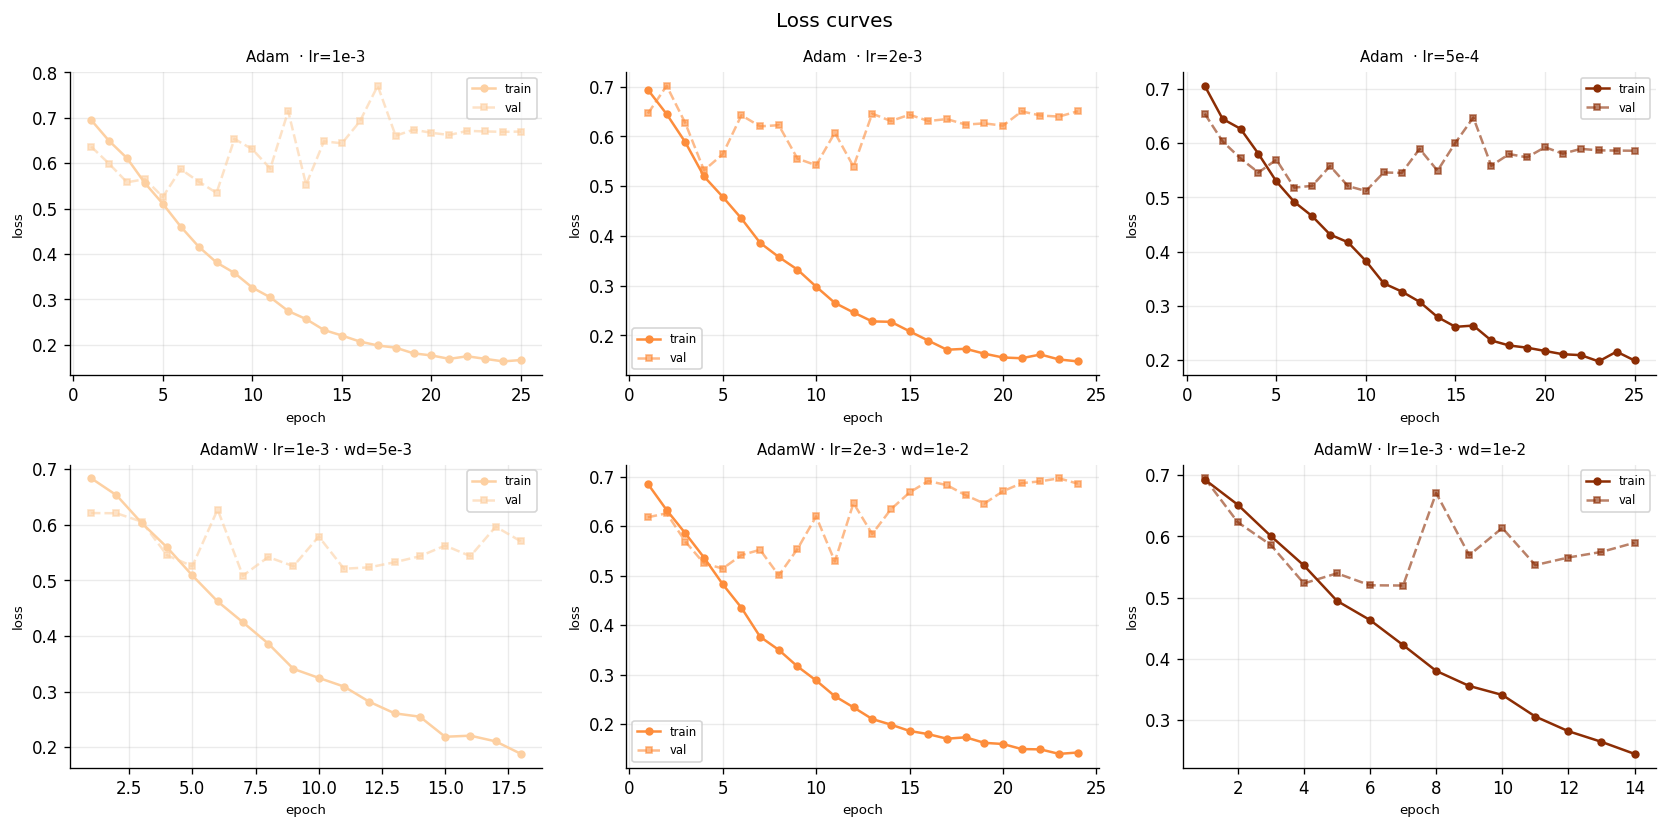

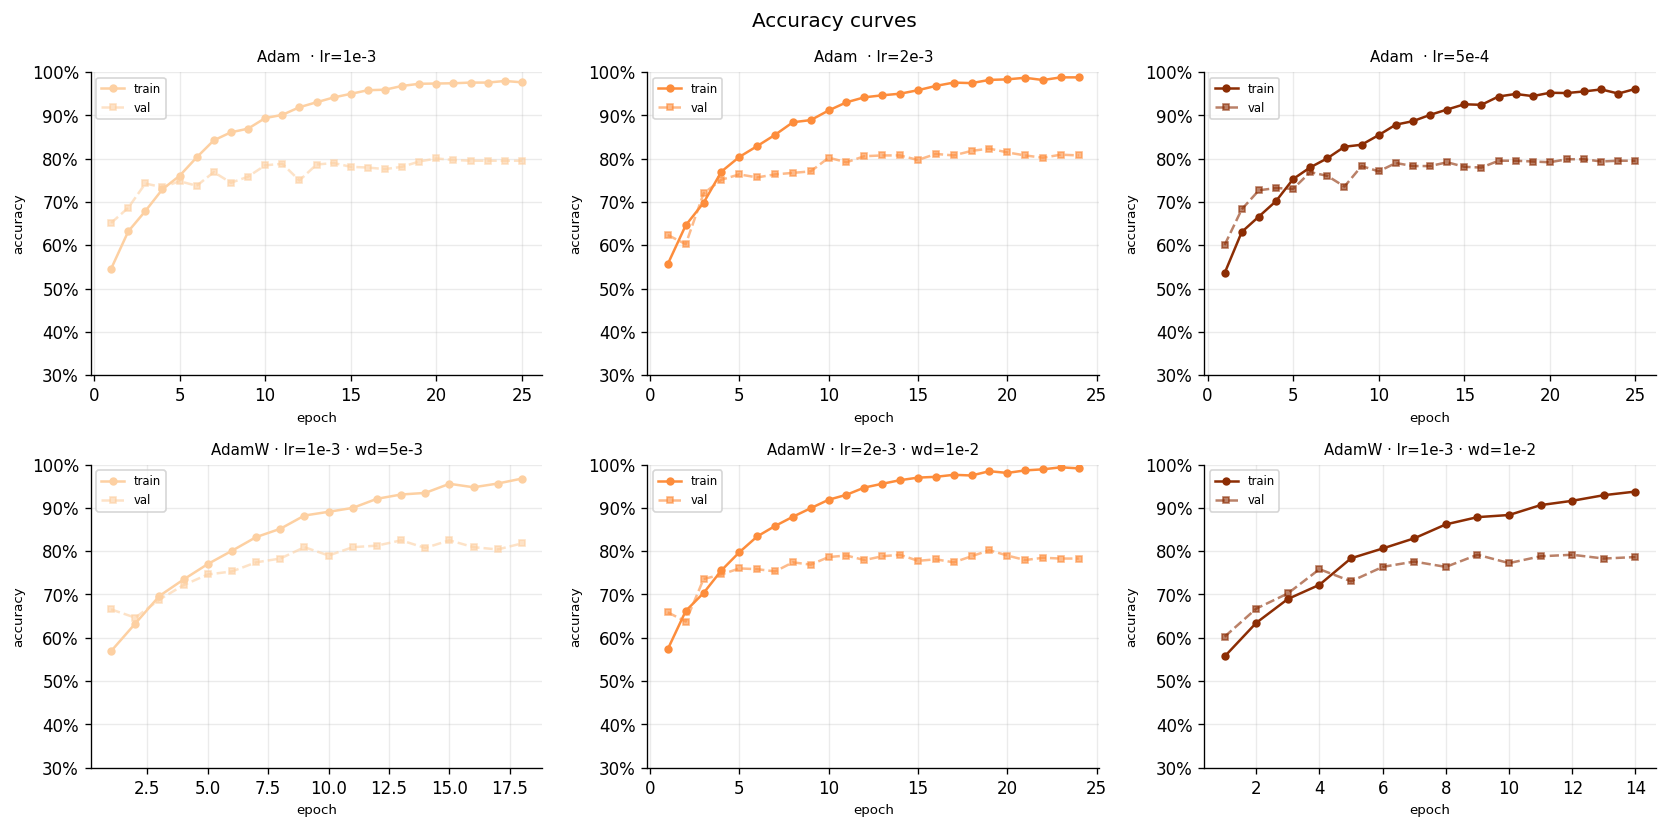

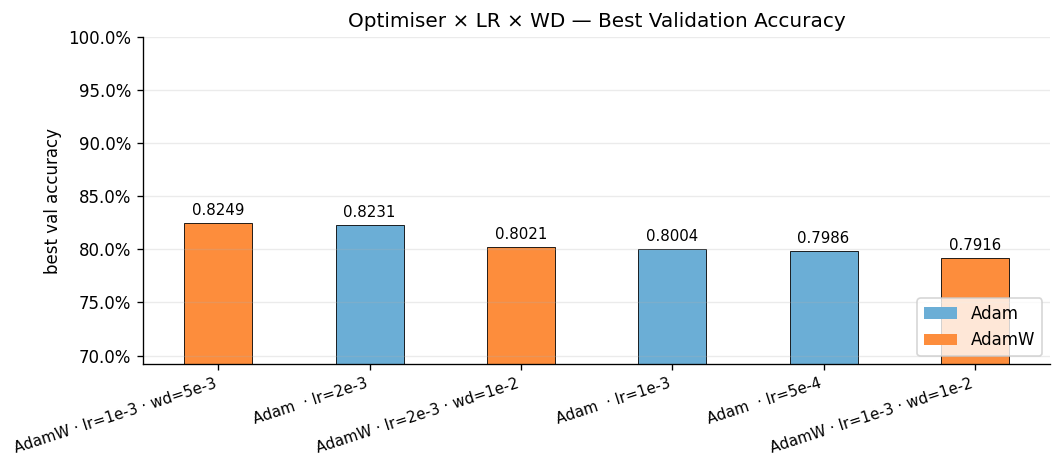

saved → loss_curves.png  acc_curves.png  comparison.png


In [11]:
n_runs   = len(run_log)
adam_pal = ['#c6dbef', '#6baed6', '#084594']
adamw_pal= ['#fdd0a2', '#fd8d3c', '#8c2d04']
pal      = adamw_pal * 3 + [adam_pal[1]]   # matches new GRID order (5 AdamW, 1 Adam)


def _ax_curves(ax, r, col, metric):
    ep_x = range(1, len(r['hist'][f'tr_{metric}']) + 1)   # adapts to early stop
    ax.plot(ep_x, r['hist'][f'tr_{metric}'], '-o',  color=col, ms=4, label='train')
    ax.plot(ep_x, r['hist'][f'va_{metric}'], '--s', color=col, ms=4, alpha=.6, label='val')
    ax.set_title(r['tag'], fontsize=9)
    ax.set_xlabel('epoch', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(alpha=.25)


# ── loss grid ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, r, c in zip(axes.flat, run_log, pal):
    _ax_curves(ax, r, c, 'loss')
    ax.set_ylabel('loss', fontsize=8)
plt.suptitle('Loss curves', fontsize=12); plt.tight_layout()
plt.savefig('loss_curves.png', bbox_inches='tight'); plt.show()

# ── accuracy grid ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, r, c in zip(axes.flat, run_log, pal):
    _ax_curves(ax, r, c, 'acc')
    ax.set_ylabel('accuracy', fontsize=8)
    ax.set_ylim(.3, 1.0)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
plt.suptitle('Accuracy curves', fontsize=12); plt.tight_layout()
plt.savefig('acc_curves.png', bbox_inches='tight'); plt.show()

# ── bar comparison ────────────────────────────────────────────────────────────
ranked = sorted(run_log, key=lambda r: r['best_acc'], reverse=True)
tags   = [r['tag']      for r in ranked]
accs   = [r['best_acc'] for r in ranked]
bpal   = [adam_pal[1] if r['opt'] == 'Adam' else adamw_pal[1] for r in ranked]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(tags, accs, color=bpal, edgecolor='k', lw=.5, width=.45)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax.set_ylim(min(accs) - .1, 1.0)
ax.set_xticklabels(tags, rotation=18, ha='right', fontsize=9)
ax.set_ylabel('best val accuracy')
ax.set_title('Optimiser × LR × WD — Best Validation Accuracy')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.grid(axis='y', alpha=.25)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(fc=adam_pal[1],  label='Adam'),
                   Patch(fc=adamw_pal[1], label='AdamW')], loc='lower right')
plt.tight_layout(); plt.savefig('comparison.png', bbox_inches='tight'); plt.show()

print("saved → loss_curves.png  acc_curves.png  comparison.png")

### Evaluate Best Model & Save

saved model.pt  (13.09 MB)   run: AdamW · lr=1e-3 · wd=5e-3



              precision    recall  f1-score   support

     foxnews     0.8268    0.8433    0.8350       300
     nbcnews     0.8226    0.8044    0.8134       271

    accuracy                         0.8249       571
   macro avg     0.8247    0.8239    0.8242       571
weighted avg     0.8248    0.8249    0.8248       571



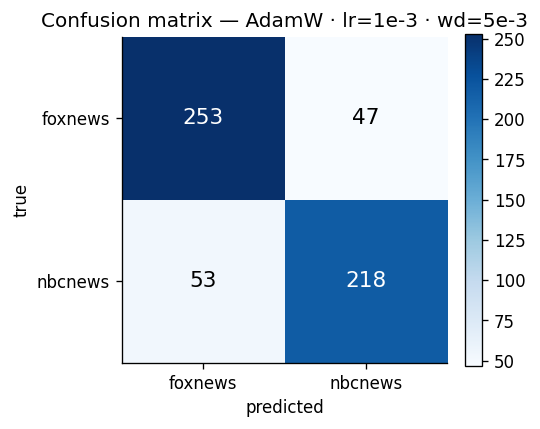

saved → confusion.png


In [12]:
# ── reload best weights ───────────────────────────────────────────────────────
net_best = _new_model()
net_best.load_state_dict({k: v.to(DEVICE) for k, v in top['snap'].items()})

torch.save({'model': net_best.state_dict(), 'vocab': tok._w2i}, CFG['ckpt'])
mb = os.path.getsize(CFG['ckpt']) / 1024**2
print(f"saved {CFG['ckpt']}  ({mb:.2f} MB)   run: {top['tag']}")

# ── classification report ─────────────────────────────────────────────────────
_, _, y_hat, y_true = probe(net_best, dl_va)

print("\n" + classification_report(
    y_true, y_hat,
    target_names=list(CFG['cls_names'].values()),
    digits=4,
))

# ── confusion matrix ──────────────────────────────────────────────────────────
cm  = confusion_matrix(y_true, y_hat)
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap='Blues')
ticks = list(CFG['cls_names'].values())
ax.set(xticks=[0,1], yticks=[0,1],
       xticklabels=ticks, yticklabels=ticks,
       xlabel='predicted', ylabel='true',
       title=f'Confusion matrix — {top["tag"]}')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=13,
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.colorbar(im, ax=ax, fraction=.046)
plt.tight_layout(); plt.savefig('confusion.png', bbox_inches='tight'); plt.show()
print("saved → confusion.png")

### Multi-Seed Ensemble

In [13]:
ENS_SEEDS = [42, 123, 456, 789, 2024]

print(f"Training ensemble: best config '{top['tag']}' × {len(ENS_SEEDS)} seeds\n")
ens_snaps = []
for seed in ENS_SEEDS:
    torch.manual_seed(seed); np.random.seed(seed)
    r = fit({**{k: top[k] for k in ('opt', 'lr', 'wd')},
             'tag': f"seed={seed}"})
    ens_snaps.append(r['snap'])

# ── ensemble inference ────────────────────────────────────────────────────────
def ens_predict(snaps, dl):
    """Average softmax probabilities over all ensemble members."""
    probs = None
    for snap in snaps:
        net = _new_model()
        net.load_state_dict({k: v.to(DEVICE) for k, v in snap.items()})
        net.eval()
        batch_probs = []
        with torch.no_grad():
            for b in dl:
                x, sl = b['x'].to(DEVICE), b['sl']
                batch_probs.append(torch.softmax(net(x, sl), -1).cpu())
        p = torch.cat(batch_probs)
        probs = p if probs is None else probs + p
    return probs

ens_probs = ens_predict(ens_snaps, dl_va)
ens_preds = ens_probs.argmax(-1).tolist()
ens_acc   = accuracy_score(y_va, ens_preds)

print(f"\nEnsemble ({len(ens_snaps)} models)  val acc = {ens_acc:.4f}")
print(classification_report(y_va, ens_preds,
      target_names=list(CFG['cls_names'].values()), digits=4))

# ── save ensemble ─────────────────────────────────────────────────────────────
torch.save({'snaps': ens_snaps, 'vocab': tok._w2i, 'cfg': CFG}, 'model_ensemble.pt')
mb = os.path.getsize('model_ensemble.pt') / 1024**2
print(f"saved model_ensemble.pt  ({mb:.2f} MB)")

Training ensemble: best config 'AdamW · lr=1e-3 · wd=5e-3' × 5 seeds


▶ seed=42   wd=0.005
  ep  1  tr 0.555/0.6880  va 0.632/0.6573 ✓
  ep  2  tr 0.612/0.6628  va 0.660/0.6697 ✓
  ep  3  tr 0.680/0.6114  va 0.723/0.5608 ✓
  ep  4  tr 0.741/0.5568  va 0.753/0.6393 ✓
  ep  5  tr 0.780/0.5010  va 0.774/0.5320 ✓
  ep  6  tr 0.807/0.4558  va 0.767/0.5029 (1/5)
  ep  7  tr 0.835/0.4205  va 0.760/0.7240 (2/5)
  ep  8  tr 0.852/0.3997  va 0.744/0.6059 (3/5)
  ep  9  tr 0.868/0.3647  va 0.790/0.5119 ✓
  ep 10  tr 0.906/0.3123  va 0.786/0.5767 (1/5)
  ep 11  tr 0.915/0.2916  va 0.778/0.5738 (2/5)
  ep 12  tr 0.923/0.2766  va 0.779/0.5761 (3/5)
  ep 13  tr 0.933/0.2558  va 0.795/0.5668 ✓
  ep 14  tr 0.939/0.2421  va 0.790/0.5920 (1/5)
  ep 15  tr 0.952/0.2217  va 0.792/0.6295 (2/5)
  ep 16  tr 0.958/0.2086  va 0.797/0.6040 ✓
  ep 17  tr 0.968/0.1888  va 0.795/0.6546 (1/5)
  ep 18  tr 0.966/0.1933  va 0.797/0.6400 (2/5)
  ep 19  tr 0.974/0.1787  va 0.807/0.6475 ✓
  ep 20  tr 0.975/0.1764  va 0.7